# Frontier: PLAN 08 Step 13 actual high-escaping charts

This notebook isolates the remaining obstruction in Step 13 after the abstract overlap-comparison theorem was formalized.

The comparison frontier is now recorded separately in `notebooks/plan08_step13_overlap_comparison_frontier.ipynb`. The present notebook focuses on the missing existence-and-packaging problem for the **actual** high-escaping chart chains.


## Current status

Already formalized:

- the canonical arbitrarily-high escaping chains,
- the abstract uniqueness/comparison theorem for logarithm branches on connected chart chains,
- the high-level wrapper interfaces `HighEscapingActualChartChainsEventuallyEqAtOverlapsData`, `HighEscapingActualChartChainsLocalLogsRestrictGlobalData`, and `HighEscapingActualChartChainsProductComparisonData`.

What this notebook now records is sharper than before:

- the previous global-log theorem candidate is **false as stated** for arbitrary basin loops;
- the obstruction already appears numerically for a large exterior circle;
- therefore the remaining Step 13 target must be weakened to a genuinely local chart-chain theorem, or else restricted to a zero-winding/high-level-image-admissibility regime.


## Numerical counterexample to the current theorem wording

Consider the exterior basin loop
$$
\gamma_R(t) = R e^{2\pi i t}, \qquad R = 5.
$$
For $c = 2$, this loop stays entirely in the basin and entirely in the outside-open region. Numerically, using an $8$-term truncation of $\text{logSeriesBottcherApprox}(2,\cdot)$, its image is a small deformation of the same circle and still winds once around $0$.

If the earlier theorem candidate were true for every loop, then for some $K \ge N_0$ the high-level image curve
$$
A_K(t) = \text{logSeriesBottcherApprox}\bigl(2, f_2^K(\gamma_R(t))\bigr)
$$
would lie in a simply connected zero-free neighborhood
$$
A_K([0,1]) \subset V \subset \mathbf{C} \setminus \{0\}
$$
carrying one holomorphic logarithm. That would force the winding number of $A_K$ around $0$ to be $0$. The computation below shows the opposite behavior numerically: the winding is already about $1$ at level $0$, and under the squaring/conjugacy picture it doubles to $2,4,8$ at the next levels.


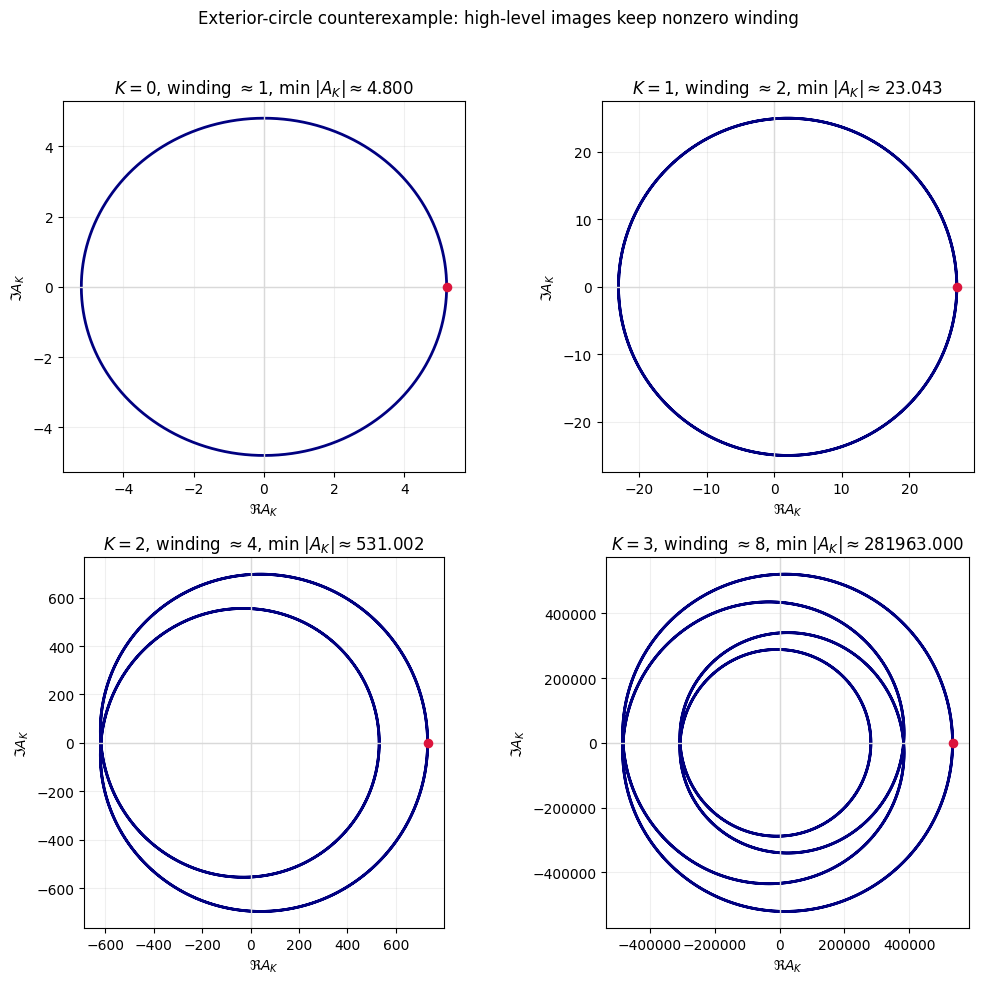

Level-0 diagnostics for finite log-series Bottcher approximation:
  winding(phi(gamma_R)) ≈ 1.0
  min |phi(gamma_R)| = 4.8003622890755935
  max |phi(gamma_R)/gamma_R - 1| = 0.040064321868088094
  min Re(phi(gamma_R)/gamma_R) = 0.9600724578151187

K=0: winding ≈ 1, min |A_K| ≈ 4.8003622890755935
K=1: winding ≈ 2, min |A_K| ≈ 23.043478106379073
K=2: winding ≈ 4, min |A_K| ≈ 531.0018832391717
K=3: winding ≈ 8, min |A_K| ≈ 281963.0000035469


In [1]:
import numpy as np
import matplotlib.pyplot as plt

c = 2.0 + 0.0j
R = 5.0
terms = 8

def f(z):
    return z * z + c

def iterate_f(z, N):
    out = np.array(z, dtype=np.complex128)
    for _ in range(N):
        out = out * out + c
    return out

def near_one_log_correction(z, N):
    zpow1 = z ** (2 ** (N + 1))
    zpow0 = z ** (2 ** N)
    den = (iterate_f(z, N) / zpow0) ** 2
    return (1 / (2 ** (N + 1))) * np.log(1 + (c / zpow1) / den)

def finite_phi(z, terms=8):
    s = np.zeros_like(z, dtype=np.complex128)
    for N in range(terms):
        s += near_one_log_correction(z, N)
    return z * np.exp(s)

def winding(values):
    ang = np.unwrap(np.angle(values))
    return (ang[-1] - ang[0]) / (2 * np.pi)

ts = np.linspace(0.0, 1.0, 4097)
zs = R * np.exp(2j * np.pi * ts)
phi_vals = finite_phi(zs, terms=terms)
ratio = phi_vals / zs
high_level_vals = [phi_vals ** (2 ** K) for K in range(4)]

fig, axes = plt.subplots(2, 2, figsize=(10.5, 10.0))
for ax, K, vals in zip(axes.flat, range(4), high_level_vals):
    ax.plot(vals.real, vals.imag, color='navy', lw=2)
    ax.scatter([vals[0].real], [vals[0].imag], color='crimson', s=35, zorder=3)
    ax.axhline(0.0, color='0.85', lw=1)
    ax.axvline(0.0, color='0.85', lw=1)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.2)
    ax.set_title(
        f'$K={K}$, winding $\\approx {winding(vals):.0f}$, '
        f'min $|A_K| \\approx {np.min(np.abs(vals)):.3f}$'
    )
    ax.set_xlabel(r'$\Re A_K$')
    ax.set_ylabel(r'$\Im A_K$')
fig.suptitle(r'Exterior-circle counterexample: high-level images keep nonzero winding', y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print('Level-0 diagnostics for finite log-series Bottcher approximation:')
print('  winding(phi(gamma_R)) ≈', winding(phi_vals))
print('  min |phi(gamma_R)| =', np.min(np.abs(phi_vals)))
print('  max |phi(gamma_R)/gamma_R - 1| =', np.max(np.abs(ratio - 1)))
print('  min Re(phi(gamma_R)/gamma_R) =', np.min(ratio.real))
print()
for K, vals in enumerate(high_level_vals):
    print(f'K={K}: winding ≈ {winding(vals):.0f}, min |A_K| ≈ {np.min(np.abs(vals))}')


The numerical picture contradicts the earlier theorem candidate exactly at its strongest point. The curves stay far from $0$, but they still wind nontrivially around $0$. Therefore there cannot exist a simply connected zero-free neighborhood $V$ containing the whole curve $A_K([0,1])$ and carrying one holomorphic logarithm for arbitrary loops.

So the positive examples from the earlier version of this notebook were not representative of the general situation. They only modeled a **special zero-winding regime** where one global logarithm exists. The large-circle example shows that this is not the generic high-escaping case.


## What “construct the actual high-escaping charts” means

For each pair $(\gamma, K)$ in the high-escaping regime, the missing object is not just a statement that some product is $1$. It is a concrete finite package:

- simply connected zero-free charts $U_0, \dots, U_m \subset \mathbf{C} \setminus \{0\}$;
- a subdivision $0 = t_0 < t_1 < \dots < t_{m+1} = 1$ such that
  $$
  A_K([t_i,t_{i+1}]) \subset U_i;
  $$
- overlap points with $U_i \cap U_{i+1} \neq \varnothing$;
- on each $U_i$, the **actual** holomorphic logarithm branch attached to the pullback root problem;
- proofs that consecutive branches match near the chosen overlap points.

This is what will eventually populate `HighEscapingActualChartChainsEventuallyEqAtOverlapsData`.

The word **actual** means that these charts and branches come from the real pullback construction needed for the basin-extension theorem, not from the canonical one-chart model available in special easy cases.


## The previous theorem candidate is too strong

The earlier notebook formulation asked for a theorem of the following shape: for every basin loop $\gamma$ and every lower bound $N_0$, there should exist some high level $K \ge N_0$ and a simply connected zero-free neighborhood
$$
A_K([0,1]) \subset V \subset \mathbf{C} \setminus \{0\}
$$
with one holomorphic logarithm $L : V \to \mathbf{C}$ whose restricted root branches produce the actual high-level chart chain.

The exterior-circle computation above shows that this is false as stated. A loop with nonzero winding around $0$ cannot be contained in any such simply connected zero-free $V$.

So the surviving theorem target must be one of the following weaker statements:

1. a **local chart-chain theorem** with no claim that one global logarithm exists on a neighborhood of the whole loop image; or
2. a **global-log theorem under an additional admissibility hypothesis**, such as zero winding of the high-level image around $0$.


## Lean target isolated by this notebook

The remaining Step 13 work is still to produce one of the packages

```lean
HighEscapingActualChartChainsEventuallyEqAtOverlapsData
HighEscapingActualChartChainsLocalLogsRestrictGlobalData
```

but the notebook evidence now splits them correctly:

- `HighEscapingActualChartChainsLocalLogsRestrictGlobalData` is a **special-case route**, valid only when the actual high-level image admits one global zero-free logarithm;
- the genuinely general Step 13 target must go through `HighEscapingActualChartChainsEventuallyEqAtOverlapsData`, where only local chart-by-chart overlap compatibility is required.

So the frontier is no longer “prove one global logarithm for every high-escaping loop.” It is “construct the actual local high-escaping chart chain and prove neighboring branch agreement without assuming zero winding globally.”
